In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("C:\\Users\\Welcome\\Downloads\\Unemployment in India.csv")
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [63]:
#data understanding
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std          

In [65]:
#data cleaning
df.columns = df.columns.str.strip()

In [67]:
#conversion
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [69]:
#check
print(df.isnull().sum())
df = df.dropna()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [71]:
#feature preparation
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

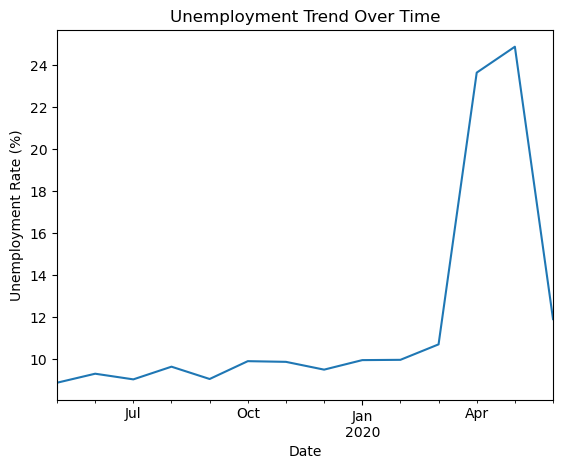

In [73]:
#data anlysis
plt.figure()
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot()
plt.title("Unemployment Trend Over Time")
plt.ylabel("Unemployment Rate (%)")
plt.show()

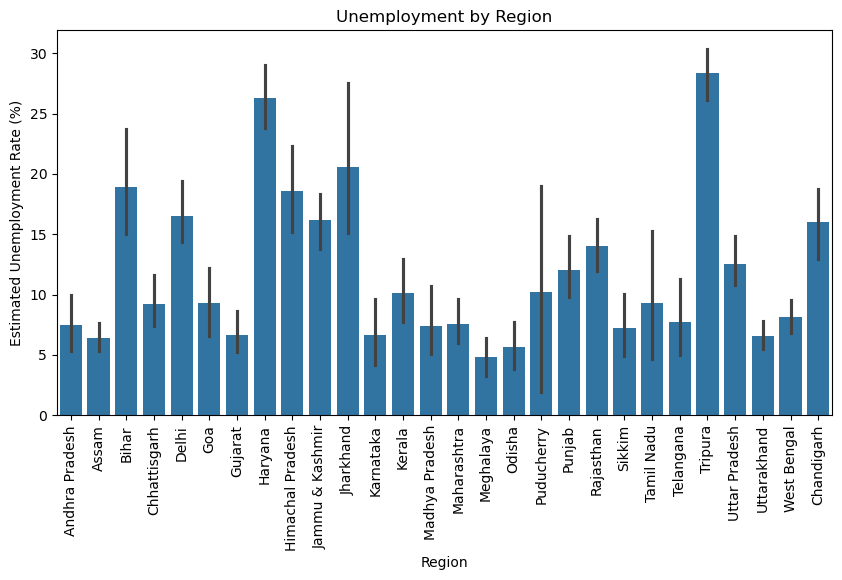

In [75]:
#region wise unemployments
plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("Unemployment by Region")
plt.show()

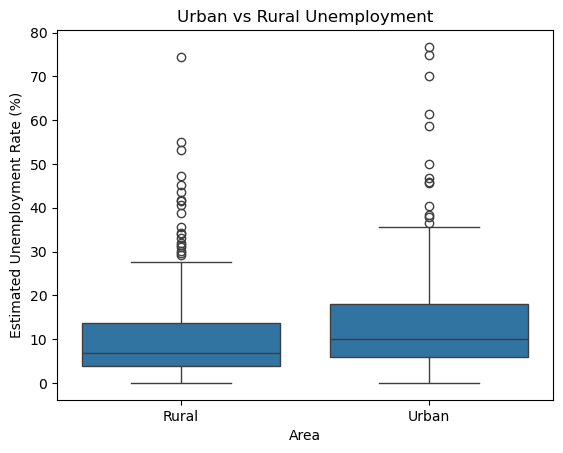

In [76]:
#urban vs rural
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Urban vs Rural Unemployment")
plt.show()

In [77]:
#covid-19 analysis
df['Covid'] = df['Date'].apply(lambda x: "Before Covid" if x < pd.to_datetime("2020-03-01") else "After Covid")

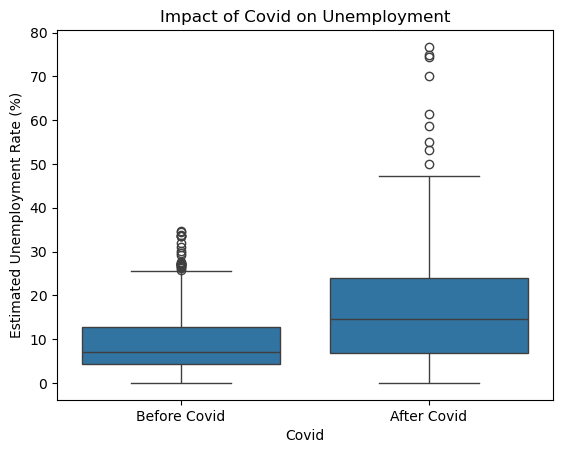

In [78]:
#before and after covid
sns.boxplot(x='Covid', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Impact of Covid on Unemployment")
plt.show()

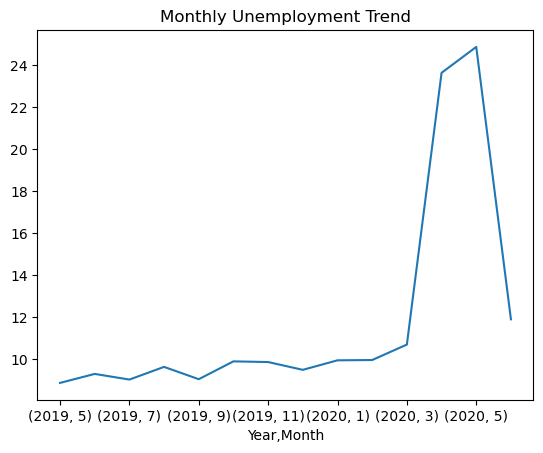

In [80]:
#monthly trend
df.groupby(['Year','Month'])['Estimated Unemployment Rate (%)'].mean().plot()
plt.title("Monthly Unemployment Trend")
plt.show()

In [82]:
print(df.groupby('Region')['Estimated Unemployment Rate (%)'].mean())
print(df.groupby('Area')['Estimated Unemployment Rate (%)'].mean())

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64
